In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import os
from torchvision.utils import make_grid

In [2]:
# ==== MODELLO ====
class CVAE(nn.Module):
    def __init__(self, latent_dim=128, cond_dim=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.cond_dim = cond_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3 + cond_dim, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Flatten()
        )
        self.encoder_out_dim = 512 * 4 * 4
        self.linear_mu = nn.Linear(self.encoder_out_dim, latent_dim)
        self.linear_log_sigma = nn.Linear(self.encoder_out_dim, latent_dim)

        self.decoder_input = nn.Linear(latent_dim + cond_dim, self.encoder_out_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x, cond):
     B, _, H, W = x.shape
     male, glasses, no_beard = cond[:, 0], cond[:, 1], cond[:, 2]
     male_tensor = male.view(-1, 1, 1, 1).expand(-1, 1, H, W).to(x.device)
     glasses_tensor = glasses.view(-1, 1, 1, 1).expand(-1, 1, H, W).to(x.device)
     no_beard_tensor = no_beard.view(-1, 1, 1, 1).expand(-1, 1, H, W).to(x.device)
     cond_maps = torch.cat([male_tensor, glasses_tensor, no_beard_tensor], dim=1)
     x_cond = torch.cat([x, cond_maps], dim=1)
 
     out = self.encoder(x_cond)
     

     mu = self.linear_mu(out)
     log_sigma = self.linear_log_sigma(out)

     
 
     eps = torch.randn_like(log_sigma)
     z = mu + eps * torch.exp(log_sigma)
    

     z_cond = torch.cat([z, cond], dim=1)
     x = self.decoder_input(z_cond).view(-1, 512, 4, 4)
     

     y = self.decoder(x)
     

     y = torch.clamp(y, 0.0, 1.0)
     return y, mu, log_sigma

In [3]:
# ==== SETUP ====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CVAE(latent_dim=128, cond_dim=3).to(device)
ckpt = torch.load("model.pt", map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

CVAE(
  (encoder): Sequential(
    (0): Conv2d(6, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Flatten(start_dim=1, end_dim=-1)
  )
  (linear_mu): Linear(in_features=8192, out_features=128, bias=True)
  (linear_log_sigma): Linear(in_features=8192, out_features=128, bias=True)
  (decoder_input): Linear(in_features=131, out_f

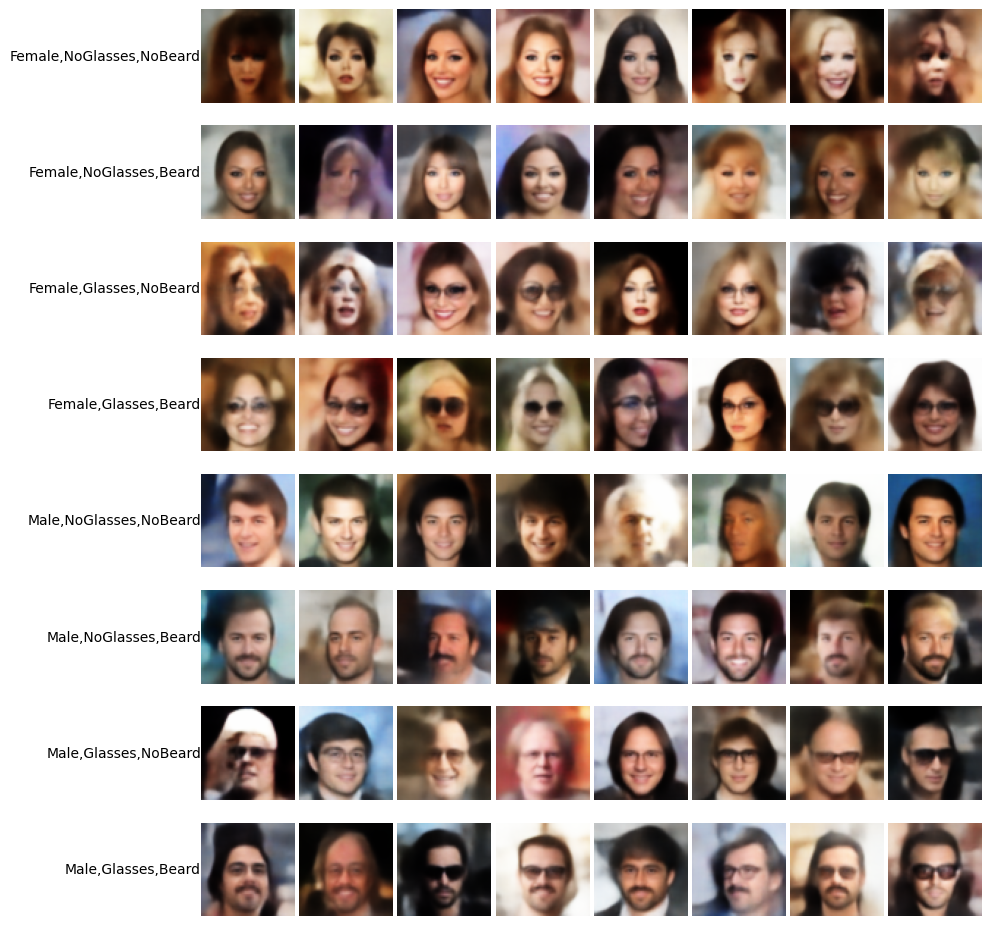

In [7]:
# ==== GENERAZIONE ====
n_per_row = 8
conditions = [
    [0, 0, 1],  # Female, No Glasses, No Beard
    [0, 0, 0],  # Female, No Glasses, Beard
    [0, 1, 1],  # Female, Glasses, No Beard
    [0, 1, 0],  # Female, Glasses, Beard
    [1, 0, 1],  # Male, No Glasses, No Beard
    [1, 0, 0],  # Male, No Glasses, Beard
    [1, 1, 1],  # Male, Glasses, No Beard
    [1, 1, 0],  # Male, Glasses, Beard
]
labels = [
    "Female,NoGlasses,NoBeard",
    "Female,NoGlasses,Beard",
    "Female,Glasses,NoBeard",
    "Female,Glasses,Beard",
    "Male,NoGlasses,NoBeard",
    "Male,NoGlasses,Beard",
    "Male,Glasses,NoBeard",
    "Male,Glasses,Beard"
]

all_rows = []
for cond in conditions:
    z = torch.randn(n_per_row, 128).to(device)
    cond_tensor = torch.tensor([cond] * n_per_row, dtype=torch.float32).to(device)
    z_cond = torch.cat([z, cond_tensor], dim=1)
    x = model.decoder_input(z_cond).view(-1, 512, 4, 4)
    with torch.no_grad():
        generated = model.decoder(x).cpu()
    all_rows.append(generated)

# ==== VISUALIZZAZIONE CON LABEL BEN VISIBILI ====
fig, axes = plt.subplots(len(all_rows), n_per_row, figsize=(n_per_row * 1.5, len(all_rows) * 1.5))

for row_idx, row_imgs in enumerate(all_rows):
    for col_idx in range(n_per_row):
        img = row_imgs[col_idx].permute(1, 2, 0).numpy()
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')

    
    axes[row_idx, 0].annotate(
        labels[row_idx],
        xy=(0, 0.5),
        xytext=(-axes[row_idx, 0].get_position().width * 2.5, 0),
        textcoords='offset points',
        fontsize=10,
        va='center',
        ha='right',
        xycoords='axes fraction'
    )


for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])


plt.subplots_adjust(left=0.25, wspace=0.05, hspace=0.05)
plt.show()